In [1]:
import numpy as np
import matplotlib.pyplot as plt
import allantools 

N = 1000 # Num of points
t = np.logspace(0, 3, 50) # tau values from 1 to 1000

# Generate noise
freq_white = allantools.noise.white(N)
freq_pink = allantools.noise.pink(N)
freq_rw = allantools.noise.brown(N)

In [4]:
def allanoadev_alt(y,t,rate):
        
    # === Parameters ===
    
    N = len(y)
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        # M is the number of times we can move the averaging window from the beginning to the end
        M = N-m[k]+1

        # Calculate allan var 
        outersum = []
        for j in np.arange(0,M-2*m[k]+1,step):
            innersum = []
            for i in np.arange(j,j+m[k]-1,step):
                innersum.append(y[i+m[k]]-y[i])
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [12]:
tau_white_alt, allanstd_white_alt = allanoadev_alt(freq_white,t,1)

In [13]:
def allanoadev_ref(freq):
    (taus, adevs, errors, ns) = allantools.oadev(freq, data_type='freq', taus = t)
    return taus, adevs, errors, ns

In [20]:
tau_white_ref, allanstd_white_ref,_,_ = allanoadev_ref(freq_white)

In [21]:
def allanoadev_opt(y,t,rate):
        
    # === Parameters ===
    
    N = len(y)
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        kernels = np.ones(m[k])/m[k]
        ybar = np.convolve(y,kernels,'valid')

        # M is the number of times we can move the averaging window from the beginning to the end
        M = len(ybar)

        # Calculate allan var 
        outersum = []
        for j in np.arange(0,M-2*m[k]+1,step):
            innersum = []
            for i in np.arange(j,j+m[k]-1,step):
                innersum.append(ybar[i+m[k]]-ybar[i])
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [22]:
tau_white_opt, allanstd_white_opt = allanoadev_opt(freq_white,t,1)

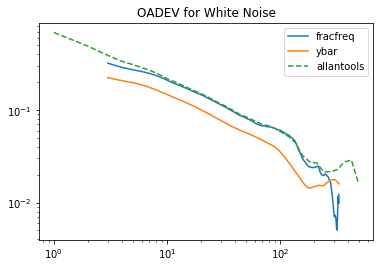

In [23]:
plt.loglog(tau_white_alt,allanstd_white_alt, label = 'fracfreq')
plt.loglog(tau_white_opt,allanstd_white_opt, label = 'ybar')
plt.loglog(allanoadev_ref(freq_white)[0],allanoadev_ref(freq_white)[1], label='allantools', linestyle='dashed')
plt.title('OADEV for White Noise')
plt.legend()

In [24]:
tau_pink_alt, allanstd_pink_alt = allanoadev_alt(freq_pink,t,1)
tau_pink_ref, allanstd_pink_ref,_,_ = allanoadev_ref(freq_pink)
tau_pink_opt, allanstd_pink_opt = allanoadev_opt(freq_pink,t,1)

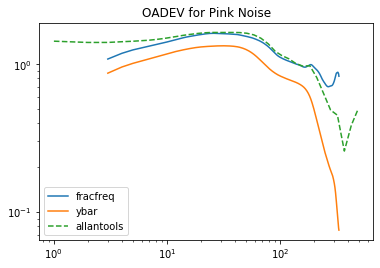

In [26]:
plt.loglog(tau_pink_alt,allanstd_pink_alt, label = 'fracfreq')
plt.loglog(tau_pink_opt, allanstd_pink_opt, label = 'ybar')
plt.loglog(tau_pink_ref,allanstd_pink_ref, label='allantools', linestyle='dashed')
plt.title('OADEV for Pink Noise')
plt.legend()

In [27]:
tau_rw_alt, allanstd_rw_alt = allanoadev_alt(freq_rw,t,1)
tau_rw_ref, allanstd_rw_ref,_,_ = allanoadev_ref(freq_rw)
tau_rw_opt, allanstd_rw_opt = allanoadev_opt(freq_rw,t,1)

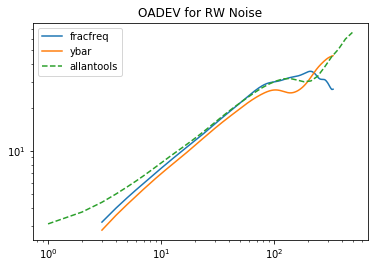

In [28]:
plt.loglog(tau_rw_alt,allanstd_rw_alt, label = 'fracfreq')
plt.loglog(tau_rw_opt, allanstd_rw_opt, label = 'ybar')
plt.loglog(tau_rw_ref,allanstd_rw_ref, label='allantools', linestyle='dashed')
plt.title('OADEV for RW Noise')
plt.legend()